<pre style="font-size: 15px; line-height: 1.2;">
---
course_code: 02BMSBI24365
course_title: AI and ML in Bioinformatics
unit: Unit 2 — Machine Learning Techniques
submodule: 2.3 Model Evaluation & Optimization
document_type: Practical Laboratory Notebook
ai_tier: Full AI (Learning Aid)
---

# 📊 Hands-On: Model Evaluation Metrics in Bioinformatics

<small><b>Course Code:</b> 02BMSBI24365 | <b>Unit 2:</b> Machine Learning Techniques (Submodule 2.3) | <b>Environment:</b> <code>gcu-aiml-bioinfo</code> | <b>AI Tier:</b> Full AI (Learning Aid)</small>

---

## Practical Objectives
1. **Classification Evaluation:** Calculate and visualize Confusion Matrices, Accuracy, Sensitivity/Recall, Precision, Specificity, and F1-Score on breast cancer biopsy diagnostics.
2. **Threshold Dynamics:** Explore how adjusting the decision threshold $\tau \in [0.1, 0.9]$ directly shifts the balance between Sensitivity and Precision.
3. **ROC-AUC Diagnostic Curves:** Plot Receiver Operating Characteristic (ROC) curves and compute the Area Under the Curve (AUC).
4. **Regression Evaluation:** Evaluate continuous clinical predictions using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and $R^2$ with residual diagnostic plots.

## Step 0: Environment Setup & Reproducible Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica, Arial, DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.edgecolor'] = '#444444'
plt.rcParams['axes.linewidth'] = 0.8
RANDOM_STATE = 42

print("✓ Core bioinformatics ML libraries imported successfully.")

✓ Core bioinformatics ML libraries imported successfully.


---
## Part 1: Classification Metrics (Diagnostic Oncology)

We evaluate a binary classification model on the **Breast Cancer Wisconsin (Diagnostic)** dataset:
* **Features ($X$):** 30 cell nucleus morphometric measurements computed from digitized fine needle aspirate (FNA) images.
* **Target ($y$):** Diagnostic pathology label: `0 = Malignant` (disease), `1 = Benign` (healthy).
* To match clinical convention, we map `1 = Malignant (Positive Case)` and `0 = Benign (Negative Case)`.

In [ ]:
# 1. Load clinical dataset
cancer_data = load_breast_cancer(as_frame=True)
X_cancer = cancer_data.data
y_raw = cancer_data.target

# Re-map target so 1 = Malignant (Case of Interest), 0 = Benign
# In sklearn's raw dataset: 0 = malignant, 1 = benign
y_cancer = (y_raw == 0).astype(int)

# Stratified split to preserve class proportions in training and test sets
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.25, random_state=RANDOM_STATE, stratify=y_cancer
)

# Scale features using training statistics only
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

# Fit Logistic Regression classifier
clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
clf.fit(X_train_c_scaled, y_train_c)

# Continuous predicted probabilities for malignant diagnosis
y_prob_c = clf.predict_proba(X_test_c_scaled)[:, 1]
# Discrete predictions at default threshold tau = 0.5
y_pred_c = (y_prob_c >= 0.5).astype(int)

print(f"Test cohort size: {len(y_test_c)} patients")
print(f"Malignant cases in test set: {sum(y_test_c)} ({sum(y_test_c)/len(y_test_c)*100:.1f}%)")

Test cohort size: 143 patients
Malignant cases in test set: 53 (37.1%)


In [34]:
y_pred_c, y_test_c.to_numpy()

(array([1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
        0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
        1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
        0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0,
        1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1,
        0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0,
        0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0]),
 array([1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
        0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
        1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
        0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
        1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1,
        0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0,
        0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0]))

### 1.1 The Confusion Matrix

The confusion matrix cross-tabulates model diagnoses against ground-truth pathology:
* **True Positive ($TP$):** Malignant biopsies correctly identified.
* **True Negative ($TN$):** Benign biopsies correctly cleared.
* **False Positive ($FP$):** Benign biopsies misdiagnosed as malignant (Type I Error).
* **False Negative ($FN$):** Malignant biopsies missed as benign (Type II Error — missed diagnosis).

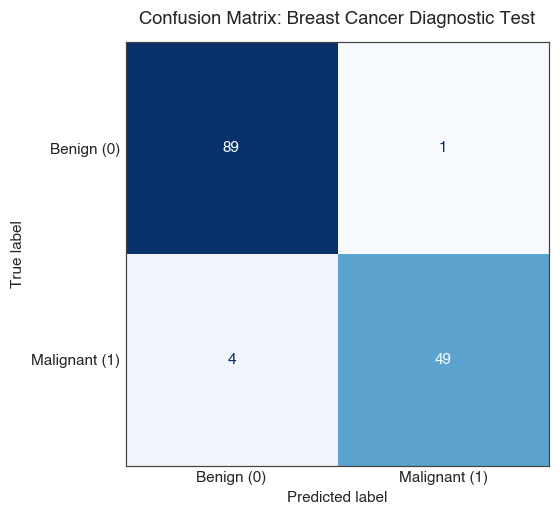

True Negatives  (TN): 89 patients correctly cleared as benign
False Positives (FP): 1 benign biopsies flagged (unnecessary alarms)
False Negatives (FN): 4 malignant cancers missed (clinical failure)
True Positives  (TP): 49 malignant tumors correctly detected


In [3]:
cm = confusion_matrix(y_test_c, y_pred_c)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign (0)', 'Malignant (1)'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title("Confusion Matrix: Breast Cancer Diagnostic Test", fontsize=12, fontweight='bold', pad=12)
plt.grid(False)
plt.show()

print(f"True Negatives  (TN): {tn} patients correctly cleared as benign")
print(f"False Positives (FP): {fp} benign biopsies flagged (unnecessary alarms)")
print(f"False Negatives (FN): {fn} malignant cancers missed (clinical failure)")
print(f"True Positives  (TP): {tp} malignant tumors correctly detected")

### 1.2 Quantitative Classification Metrics

We extract quantitative metrics from the matrix counts:
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$
$$\text{Sensitivity / Recall} = \frac{TP}{TP + FN}$$
$$\text{Precision} = \frac{TP}{TP + FP}$$
$$\text{Specificity} = \frac{TN}{TN + FP}$$
$$F_1\text{-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

In [4]:
# Manual computation from matrix counts
accuracy = (tp + tn) / (tp + tn + fp + fn)
recall = tp / (tp + fn)
precision = tp / (tp + fp)
specificity = tn / (tn + fp)
f1 = 2 * (precision * recall) / (precision + recall)

print("=== Diagnostic Metric Summary ===")
print(f"Accuracy:    {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Sensitivity: {recall:.4f} ({recall*100:.2f}% of true cancers detected)")
print(f"Precision:   {precision:.4f} ({precision*100:.2f}% of flagged patients actually have cancer)")
print(f"Specificity: {specificity:.4f} ({specificity*100:.2f}% of healthy patients cleared)")
print(f"F1-Score:    {f1:.4f}")

# Scikit-learn classification report verification
print("\n=== Scikit-learn Classification Report ===")
print(classification_report(y_test_c, y_pred_c, target_names=['Benign', 'Malignant'], digits=4))

=== Diagnostic Metric Summary ===
Accuracy:    0.9650 (96.50%)
Sensitivity: 0.9245 (92.45% of true cancers detected)
Precision:   0.9800 (98.00% of flagged patients actually have cancer)
Specificity: 0.9889 (98.89% of healthy patients cleared)
F1-Score:    0.9515

=== Scikit-learn Classification Report ===
              precision    recall  f1-score   support

      Benign     0.9570    0.9889    0.9727        90
   Malignant     0.9800    0.9245    0.9515        53

    accuracy                         0.9650       143
   macro avg     0.9685    0.9567    0.9621       143
weighted avg     0.9655    0.9650    0.9648       143



### 1.3 Decision Threshold ($\tau$) Dynamics

Binary classifiers estimate a posterior probability $P(\text{Malignant} \mid X)$. By adjusting the operating decision threshold $\tau$, we directly control clinical risk:
* **Low threshold ($\tau = 0.2$):** Flags samples with $\ge 20\%$ probability as malignant. Maximizes Sensitivity (minimizes missed cases).
* **High threshold ($\tau = 0.8$):** Flags samples only when $\ge 80\%$ certain. Maximizes Precision (minimizes false alarms).

In [5]:
thresholds = [0.10, 0.25, 0.50, 0.75, 0.90]
results = []

for tau in thresholds:
    preds = (y_prob_c >= tau).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test_c, preds).ravel()
    sens = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    prec = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
    spec = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0
    f1_t = 2 * (prec * sens) / (prec + sens) if (prec + sens) > 0 else 0
    results.append({
        'Threshold (tau)': tau,
        'TP': tp_t, 'FN (Missed)': fn_t, 'FP (Alarms)': fp_t,
        'Sensitivity': sens, 'Precision': prec, 'Specificity': spec, 'F1-Score': f1_t
    })

threshold_df = pd.DataFrame(results)
threshold_df

,Threshold (tau),TP,FN (Missed),FP (Alarms),Sensitivity,Precision,Specificity,F1-Score
0,0.10,52,1,6,0.981132,0.896552,0.933333,0.936937
1,0.25,51,2,2,0.962264,0.962264,0.977778,0.962264
2,0.50,49,4,1,0.924528,0.980000,0.988889,0.951456
3,0.75,46,7,0,0.867925,1.000000,1.000000,0.929293
4,0.90,43,10,0,0.811321,1.000000,1.000000,0.895833


### 1.4 Receiver Operating Characteristic (ROC) & AUC Curve

The ROC curve measures diagnostic discrimination across all possible operating thresholds $\tau \in [0, 1]$:
* **Y-axis:** True Positive Rate (Sensitivity)
* **X-axis:** False Positive Rate ($1 - \text{Specificity}$)

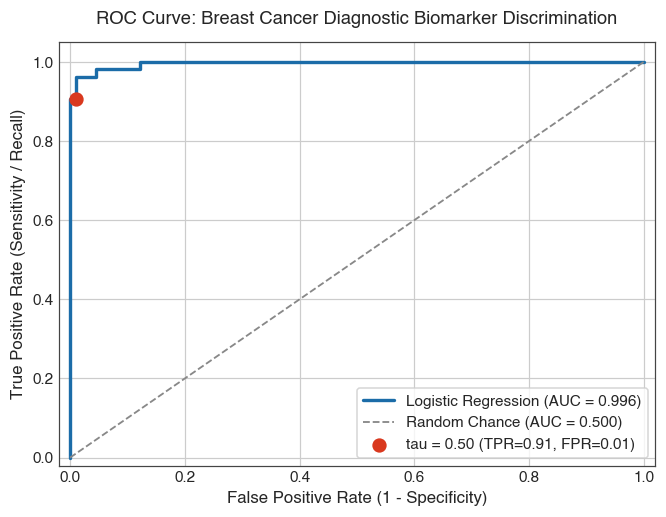

In [6]:
fpr, tpr, roc_thresholds = roc_curve(y_test_c, y_prob_c)
auc_score = roc_auc_score(y_test_c, y_prob_c)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#1b6ca8', lw=2.2, label=f'Logistic Regression (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1], color='#888888', linestyle='--', lw=1.2, label='Random Chance (AUC = 0.500)')

# Annotate specific operating point at default threshold 0.5
idx_50 = np.argmin(np.abs(roc_thresholds - 0.5))
ax.scatter(fpr[idx_50], tpr[idx_50], color='#d9381e', s=70, zorder=5, label=f'tau = 0.50 (TPR={tpr[idx_50]:.2f}, FPR={fpr[idx_50]:.2f})')

ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
ax.set_title('ROC Curve: Breast Cancer Diagnostic Biomarker Discrimination', fontsize=12, fontweight='bold', pad=12)
ax.legend(loc='lower right', frameon=True)
plt.show()

---
## Part 2: Regression Metrics (Quantitative Endocrinology)

We evaluate continuous prediction models on the **Diabetes Progression** cohort:
* **Features ($X$):** 10 physiological variables (age, sex, body mass index, average blood pressure, six serum lipid/protein measurements).
* **Target ($y$):** Quantitative disease progression score measured one year after baseline.

In [7]:
# 1. Load quantitative regression dataset
diabetes_data = load_diabetes(as_frame=True)
X_diab = diabetes_data.data
y_diab = diabetes_data.target

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_diab, y_diab, test_size=0.20, random_state=RANDOM_STATE
)

# Standardize features
scaler_r = RobustScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

# Fit Ridge Regression model
reg = Ridge(alpha=1.0, random_state=RANDOM_STATE)
reg.fit(X_train_r_scaled, y_train_r)

# Generate continuous predictions
y_pred_r = reg.predict(X_test_r_scaled)

print(f"Target range: {y_diab.min():.1f} to {y_diab.max():.1f}")
print(f"Test cohort size: {len(y_test_r)} patients")

Target range: 25.0 to 346.0
Test cohort size: 89 patients


### 2.1 Computing Regression Metrics: MAE, MSE, RMSE, and $R^2$

* **Mean Absolute Error (MAE):** $\frac{1}{N}\sum |y_i - \hat{y}_i|$ (linear average error).
* **Mean Squared Error (MSE):** $\frac{1}{N}\sum (y_i - \hat{y}_i)^2$ (quadratic penalty).
* **Root Mean Squared Error (RMSE):** $\sqrt{\text{MSE}}$ (penalizes outliers in original units).
* **$R^2$ Score:** $1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}}$ (fraction of biological variance captured).

In [61]:
mae = mean_absolute_error(y_test_r, y_pred_r)
mse = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_r, y_pred_r)

print("=== Continuous Prediction Metric Summary ===")
print(f"Mean Absolute Error (MAE):       {mae:.2f} progression points")
print(f"Mean Squared Error (MSE):        {mse:.2f} points²")
print(f"Root Mean Squared Error (RMSE):   {rmse:.2f} progression points")
print(f"Coefficient of Determination (R²): {r2:.4f} ({r2*100:.1f}% variance explained)")

=== Continuous Prediction Metric Summary ===
Mean Absolute Error (MAE):       42.83 progression points
Mean Squared Error (MSE):        2887.75 points²
Root Mean Squared Error (RMSE):   53.74 progression points
Coefficient of Determination (R²): 0.4550 (45.5% variance explained)


### 2.2 Residual Diagnostics

Plotting observed values vs. predictions and analyzing prediction residuals ($e_i = y_i - \hat{y}_i$) reveals systematic bias or variance instability.

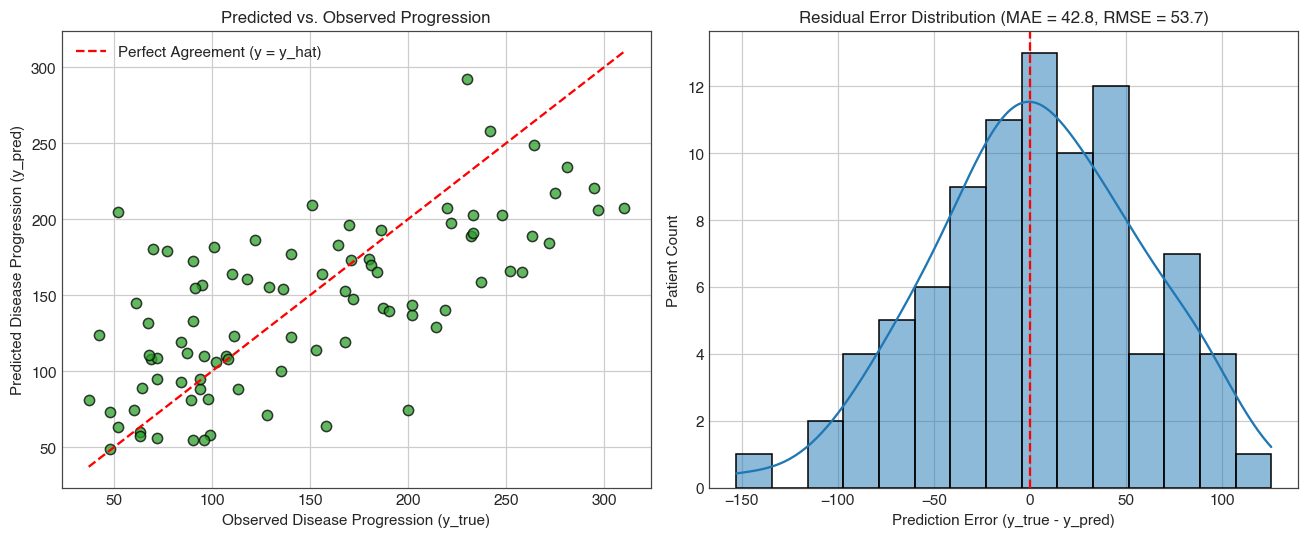

In [9]:
residuals = y_test_r - y_pred_r

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Observed vs Predicted
axes[0].scatter(y_test_r, y_pred_r, color='#2ca02c', alpha=0.75, edgecolor='black', s=45)
axes[0].plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=1.5, label='Perfect Agreement (y = y_hat)')
axes[0].set_xlabel('Observed Disease Progression (y_true)', fontsize=10)
axes[0].set_ylabel('Predicted Disease Progression (y_pred)', fontsize=10)
axes[0].set_title('Predicted vs. Observed Progression', fontsize=11, fontweight='bold')
axes[0].legend()

# Plot 2: Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[1], color='#1f77b4', edgecolor='black', bins=15)
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Prediction Error (y_true - y_pred)', fontsize=10)
axes[1].set_ylabel('Patient Count', fontsize=10)
axes[1].set_title(f'Residual Error Distribution (MAE = {mae:.1f}, RMSE = {rmse:.1f})', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Diagnostic Strategy Formulation

Consider the quantitative outputs generated above:
1. In the Breast Cancer task, if you were deploying this model as a **first-line mobile screening test in an underserved clinic**, what threshold $\tau$ would you select from Section 1.3 and why?
2. In the Diabetes regression task, notice that RMSE is larger than MAE. Why does this occur mathematically, and what does this difference indicate about patient-specific outliers?